### PCA Plots
Compares and plots the vectors at each cycle of backpropagation, constructed with vectors from the finalized embeddings.

In [5]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import json
import os
os.makedirs("../plots/pca", exist_ok=True)




def pca_plot(data, fpath, comparing):
    points = []
    for word in comparing:
        points.extend([word, np.array(row)] for row in data[word])
    random.shuffle(points)
    labels = np.array([point[0] for point in points])
    lookup, clabels = np.unique(labels, return_inverse=True)
    vectors = np.array([point[1] for point in points])

    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(vectors)

    #cmap = plt.cm.get_cmap('tab10', len(comparing))
    cmap = plt.get_cmap('tab10', len(comparing))

    plt.figure(figsize=(5,5))
    plt.scatter(features_pca[:,0], features_pca[:,1], c=clabels, cmap='tab10', s=5, marker='.')

    # Add the axis labels
    plt.xlabel('PC 1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
    plt.ylabel('PC 2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100)) 
    plt.legend([mpatches.Patch(color=cmap(b)) for b in range(len(comparing))], lookup)
    plt.title(fpath.split('/')[-1].split('.')[0])

    plt.savefig(fpath, dpi=300)
    plt.show()

In [6]:
# load data generated form indiv_word_representations.ipynb
with open('../data/indiv_word_representations/generate_vector_from_bloom.json', 'r') as f:
    vectors_from_bloom = json.load(f)
with open('../data/indiv_word_representations/generate_vector_from_iterative_vectors.json', 'r') as f:
    vectors_from_iterative_vectors = json.load(f)

### Create PCA plots for a set of words

These words must be in the file generated in indiv_word_representations.ipynb

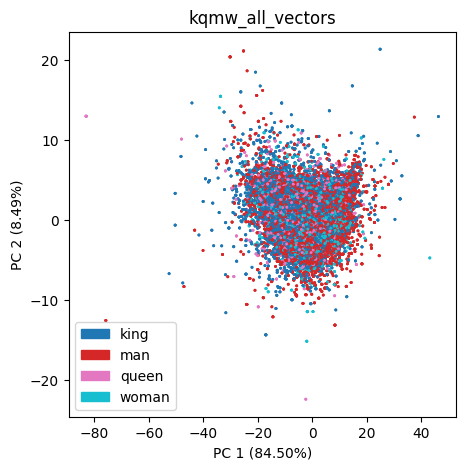

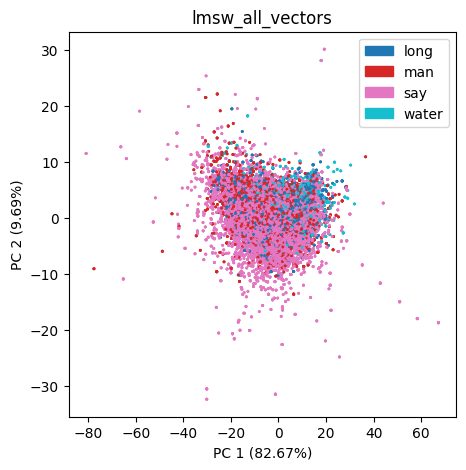

Plots Created


In [9]:
set1 = ["king", "queen", "man", "woman"]
set2 = ["long", "man", "say", "water"]
pca_plot(vectors_from_iterative_vectors, 'pca/kqmw_all_vectors.png', set1)
pca_plot(vectors_from_iterative_vectors, 'pca/lmsw_all_vectors.png', set2)
print("Plots Created")

### PCA Plots every xth vector (every 10th update to the final vector)

These words must be in the file generated in indiv_word_representations.ipynb

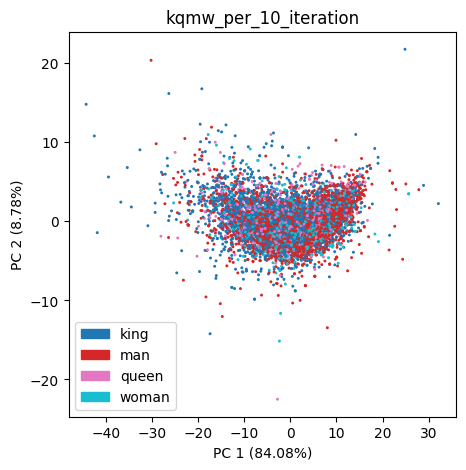

In [8]:
wanted_words = ["king", "queen", "man", "woman"]


with open('../data/indiv_word_representations/generate_vector_from_iterative_vectors.json', 'r') as f:
    iteration_data = json.load(f)

filtered_data = {
    word: iteration_data[word]
    for word in wanted_words
    if word in iteration_data
}

sampled_filtered = {}

for word in wanted_words:
    if word in iteration_data:
        vectors = iteration_data[word]
        sampled_filtered[word] = vectors[::10]  
        # Takes every tenth vector

pca_plot(sampled_filtered, 'pca/kqmw_per_10_iteration.png', wanted_words)